In [77]:
import pandas as pd
import matplotlib.pyplot as plt


In [78]:
df = pd.read_csv("emissions.csv", sep =",")
df

,Category,Initial_PA.Nylon,Initial_PA_return,Targeted_PA.Nylon,Targeted_PA_return,Incentive_PA.Nylon,Incentive_PA_return,Normal_PA.Nylon,Normal_PA_return,Initial_PES,...,Normal_CO_return,Initial_LI_Flax,Initial_LI_return,Targeted_LI_Flax,Targeted_LI_return,Incentive_LI_Flax,Incentive_LI_return,Normal_LI_Flax,Normal_LI_return,Unit
0,"Climate change, incl biogenic carbon",9597.959,7085.040,9445.184,7015.472,9031.978,6731.090,9521.986,7036.941,145511.865,...,602.020,74.784,53.224,74.784,53.224,73.406,52.536,74.094,52.536,kg CO2-Eq
1,Freshwater aquatic ecotoxicity,35.533,26.230,34.968,25.973,33.438,24.920,35.252,26.052,4724.477,...,59.224,3.974,2.828,3.974,2.828,3.901,2.792,3.937,2.792,kg 1.4 DCB eq.
2,Marine aquatic ecotoxicity,49.000,36.171,48.220,35.815,46.110,34.364,48.612,35.925,6315.233,...,48.337,4.588,3.265,4.588,3.265,4.503,3.223,4.546,3.223,kg 1.4 DCB eq.
3,Terrestrial ecotoxicity,2257.508,1666.452,2221.574,1650.089,2124.385,1583.200,2239.639,1655.138,535417.090,...,2052.612,317.894,226.248,317.894,226.248,312.039,223.323,314.964,223.323,kg 1.4 DCB eq.
4,Freshwater Eutrophication,0.500,0.369,0.492,0.366,0.471,0.351,0.496,0.367,37.767,...,0.558,0.025,0.018,0.025,0.018,0.024,0.018,0.025,0.018,kg P eq.
5,Marine Eutrophication,2.778,2.050,2.734,2.030,2.614,1.948,2.756,2.037,12.895,...,5.449,0.252,0.179,0.252,0.179,0.247,0.177,0.249,0.177,kg N eq.
6,Terrestrial Acidification,27.144,20.037,26.712,19.840,25.543,19.036,26.929,19.901,403.199,...,7.421,1.080,0.769,1.080,0.769,1.060,0.759,1.070,0.759,kg SO2 eq.
7,Photochemical Ozone Formation. Ecosystems,17.234,12.722,16.960,12.597,16.218,12.087,17.098,12.636,383.569,...,2.402,0.356,0.253,0.356,0.253,0.350,0.250,0.353,0.250,kg NOx eq.
8,lonizing Radiation,1.743,1.287,1.715,1.274,1.640,1.222,1.729,1.278,7296.447,...,8.412,1.519,1.081,1.519,1.081,1.491,1.067,1.505,1.067,kBq Co-60 eq.
9,"Human toxicity, cancer",181.077,133.668,178.195,132.355,170.399,126.990,179.644,132.761,7198.569,...,25.960,3.746,2.666,3.746,2.666,3.677,2.631,3.711,2.631,kg 1.4-DB eq


In [79]:
df = df[df.Category.isin(["Climate change, incl biogenic carbon",
"Freshwater aquatic ecotoxicity",
"Terrestrial ecotoxicity",
"Human toxicity, cancer",
"Human toxicity, non-cancer",
"Fossil depletion"])].reset_index()
df.Category = df.Category.str.replace(',', '\n')
df.Category = df.Category + " in " + df.Unit
df

,index,Category,Initial_PA.Nylon,Initial_PA_return,Targeted_PA.Nylon,Targeted_PA_return,Incentive_PA.Nylon,Incentive_PA_return,Normal_PA.Nylon,Normal_PA_return,...,Normal_CO_return,Initial_LI_Flax,Initial_LI_return,Targeted_LI_Flax,Targeted_LI_return,Incentive_LI_Flax,Incentive_LI_return,Normal_LI_Flax,Normal_LI_return,Unit
0,0,Climate change\n incl biogenic carbon in kg CO...,9597.959,7085.040,9445.184,7015.472,9031.978,6731.090,9521.986,7036.941,...,602.020,74.784,53.224,74.784,53.224,73.406,52.536,74.094,52.536,kg CO2-Eq
1,1,Freshwater aquatic ecotoxicity in kg 1.4 DCB eq.,35.533,26.230,34.968,25.973,33.438,24.920,35.252,26.052,...,59.224,3.974,2.828,3.974,2.828,3.901,2.792,3.937,2.792,kg 1.4 DCB eq.
2,3,Terrestrial ecotoxicity in kg 1.4 DCB eq.,2257.508,1666.452,2221.574,1650.089,2124.385,1583.200,2239.639,1655.138,...,2052.612,317.894,226.248,317.894,226.248,312.039,223.323,314.964,223.323,kg 1.4 DCB eq.
3,9,Human toxicity\n cancer in kg 1.4-DB eq,181.077,133.668,178.195,132.355,170.399,126.990,179.644,132.761,...,25.960,3.746,2.666,3.746,2.666,3.677,2.631,3.711,2.631,kg 1.4-DB eq
4,10,Human toxicity\n non-cancer in kg 1.4-DB eq,596.717,440.486,587.219,436.161,561.530,418.480,591.994,437.496,...,1056.275,-108.060,-76.907,-108.060,-76.907,-106.070,-75.913,-107.064,-75.913,kg 1.4-DB eq
5,15,Fossil depletion in kg oil eq.,2990.261,2207.357,2942.664,2185.683,2813.929,2097.083,2966.592,2192.372,...,98.232,13.575,9.661,13.575,9.661,13.325,9.536,13.449,9.536,kg oil eq.


In [80]:
start_indices = range(2, len(df.columns)-1, 8)
sums = pd.concat([df.Category, df.iloc[:, [start_index for start_index in start_indices]]], axis=1)
df

,Category,Initial_PA.Nylon,Initial_PES,Initial_EL_Polyurethane,Initial_CV_Viscos,Initial_CO_Cotton,Initial_LI_Flax
0,Climate change\n incl biogenic carbon in kg CO...,9597.959,145511.865,4045.629,999.944,803.132,74.784
1,Freshwater aquatic ecotoxicity in kg 1.4 DCB eq.,35.533,4724.477,193.644,44.739,79.009,3.974
2,Terrestrial ecotoxicity in kg 1.4 DCB eq.,2257.508,535417.090,16366.205,5861.727,2738.313,317.894
3,Human toxicity\n cancer in kg 1.4-DB eq,181.077,7198.569,244.339,52.308,34.632,3.746
4,Human toxicity\n non-cancer in kg 1.4-DB eq,596.717,104451.832,3529.238,1148.889,1409.137,-108.060
5,Fossil depletion in kg oil eq.,2990.261,63355.637,1590.918,239.993,131.047,13.575


<Axes: xlabel='Category'>

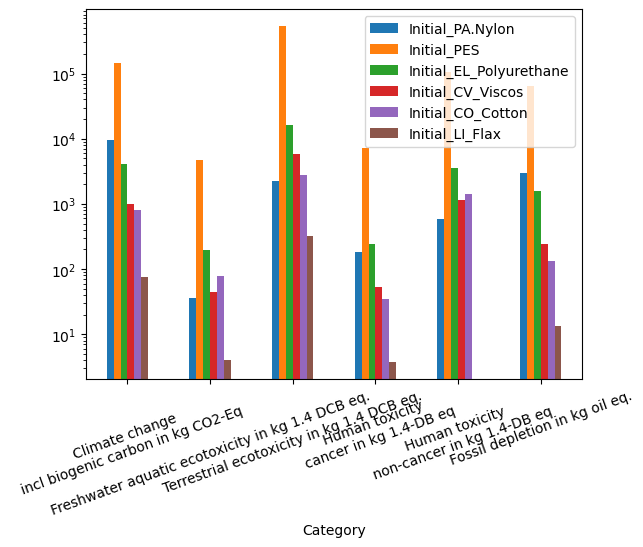

In [88]:
df.plot.bar(logy = True, x='Category', rot=20, stacked = False)

In [82]:
df.iloc[:, 1:-1].plot.bar(logy = True, x='Category', rot=20, stacked = True)

KeyError: 'Category'